# 02 — Transformer Quickstart

This notebook demonstrates Sentinel's **Transformer** module:
- `RollingAggregator` for rolling window aggregations
- `StringAggregator` for time-window categorical aggregation
- `custom_metrics` for cross-column, domain-specific logic

We use real HSM (Hardware Security Module) log data from `data/structured_logs.csv` (~87K entries).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sentinel.transformer import RollingAggregator, StringAggregator

## Load and Prepare Data

In [2]:
raw = pd.read_csv('data/structured_logs.csv')
print(f"Raw shape: {raw.shape}")
print(f"Columns: {list(raw.columns)}")
raw.head()

Raw shape: (87688, 6)
Columns: ['date', 'time', 'level', 'ip', 'category', 'message']


,date,time,level,ip,category,message
0,2025 Feb 7,13:00:01,notice,10.2.1.20,System,Log rotation: Successfully rotated Activity Log.
1,2025 Feb 7,13:00:17,notice,10.2.1.20,Host Listener,Accepted connection 1 from Client:10.8.63.24 o...
2,2025 Feb 7,13:00:17,notice,10.2.1.20,Host Listener,Accepted connection 2 from Client:10.8.63.24 o...
3,2025 Feb 7,13:00:17,notice,10.2.1.20,Host Listener,"Listener(Port 8005, NIC 1) - socket 23 closed"
4,2025 Feb 7,13:00:17,notice,10.2.1.20,Host Listener,"Listener(Port 8005, NIC 1) - socket 24 closed"


In [3]:
# Combine date + time into a single timestamp
raw['timestamp'] = pd.to_datetime(raw['date'] + ' ' + raw['time'], format='mixed')
raw = raw.sort_values('timestamp').reset_index(drop=True)

print(f"Time range: {raw['timestamp'].min()} → {raw['timestamp'].max()}")
print(f"Duration: {raw['timestamp'].max() - raw['timestamp'].min()}")
print(f"\nLevel distribution:")
print(raw['level'].value_counts())
print(f"\nCategory distribution:")
print(raw['category'].value_counts())

Time range: 2024-10-31 02:00:01 → 2025-02-12 10:02:13
Duration: 104 days 08:02:12

Level distribution:
level
notice         83772
debug           3896
information       18
critical           1
alert              1
Name: count, dtype: int64

Category distribution:
category
Host Listener      76657
ACS                 6967
SNMP Agent          3622
System               421
Process Monitor        9
Logger                 7
Front Panel            5
Name: count, dtype: int64


---
## 1. RollingAggregator

The `RollingAggregator` computes rolling window statistics on numeric columns. Since our log data is categorical, we first create a numeric time series by counting events per minute, then apply rolling aggregations to smooth the signal.

In [4]:
# Create event count per minute
events_per_min = (
    raw.set_index('timestamp')
    .resample('1min')
    .size()
    .rename('event_count')
    .reset_index()
)

print(f"Time series shape: {events_per_min.shape}")
events_per_min.head(10)

Time series shape: (150243, 2)


,timestamp,event_count
0,2024-10-31 02:00:00,1
1,2024-10-31 02:01:00,0
2,2024-10-31 02:02:00,3
3,2024-10-31 02:03:00,0
4,2024-10-31 02:04:00,0
5,2024-10-31 02:05:00,0
6,2024-10-31 02:06:00,0
7,2024-10-31 02:07:00,3
8,2024-10-31 02:08:00,0
9,2024-10-31 02:09:00,0


In [5]:
# Apply rolling mean and std with a 30-minute window
transformer = RollingAggregator(
    window_size=30,
    aggregation_functions=['mean', 'std', 'max'],
    columns='event_count',
)

rolled = transformer.fit_transform(events_per_min)
print("New columns:", [c for c in rolled.columns if 'rolling' in c])
rolled.dropna().head(10)

New columns: ['event_count_rolling_mean', 'event_count_rolling_std', 'event_count_rolling_max']


,timestamp,event_count,event_count_rolling_mean,event_count_rolling_std,event_count_rolling_max
29,2024-10-31 02:29:00,0,0.666667,1.295439,4.0
30,2024-10-31 02:30:00,0,0.633333,1.299425,4.0
31,2024-10-31 02:31:00,0,0.633333,1.299425,4.0
32,2024-10-31 02:32:00,3,0.633333,1.299425,4.0
33,2024-10-31 02:33:00,0,0.633333,1.299425,4.0
34,2024-10-31 02:34:00,0,0.633333,1.299425,4.0
35,2024-10-31 02:35:00,0,0.633333,1.299425,4.0
36,2024-10-31 02:36:00,0,0.633333,1.299425,4.0
37,2024-10-31 02:37:00,3,0.633333,1.299425,4.0
38,2024-10-31 02:38:00,0,0.633333,1.299425,4.0


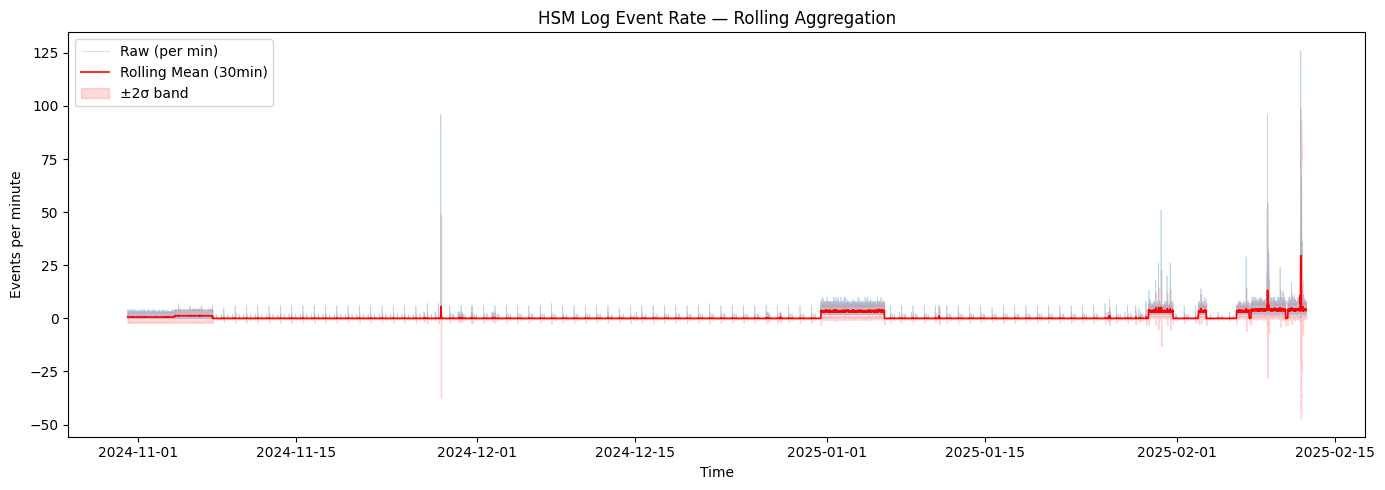

In [6]:
# Visualize original vs rolling mean with ±2σ bands
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(rolled['timestamp'], rolled['event_count'], alpha=0.3, linewidth=0.5, label='Raw (per min)')
ax.plot(rolled['timestamp'], rolled['event_count_rolling_mean'],
        label='Rolling Mean (30min)', color='red', linewidth=1.2)
ax.fill_between(
    rolled['timestamp'],
    rolled['event_count_rolling_mean'] - 2 * rolled['event_count_rolling_std'],
    rolled['event_count_rolling_mean'] + 2 * rolled['event_count_rolling_std'],
    alpha=0.15, color='red', label='±2σ band',
)
ax.set_title('HSM Log Event Rate — Rolling Aggregation')
ax.set_ylabel('Events per minute')
ax.set_xlabel('Time')
ax.legend()
plt.tight_layout()
plt.show()

## 2. EWM (Exponentially Weighted Moving) Window

EWM gives more weight to recent observations, making it more responsive to sudden changes.

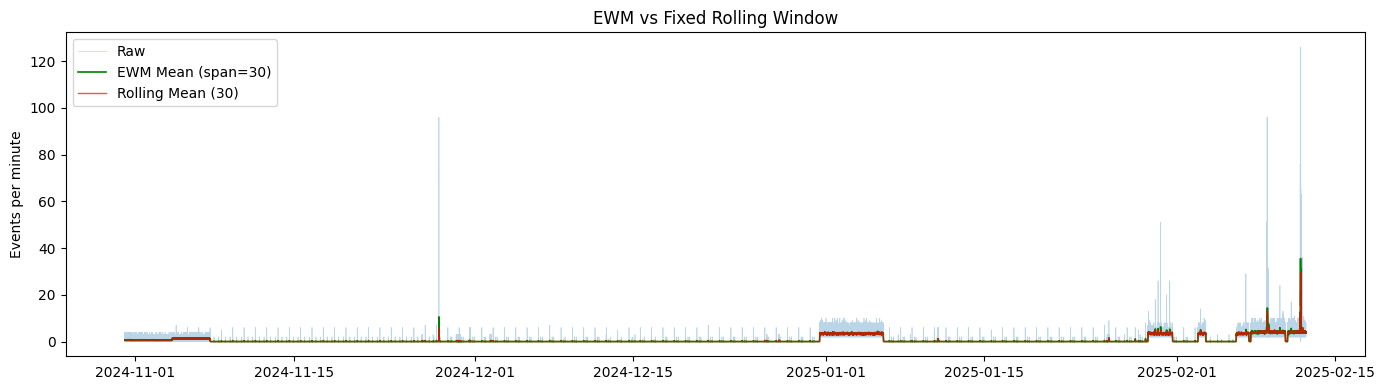

In [7]:
ewm_transformer = RollingAggregator(
    window_size=30,
    aggregation_functions=['mean'],
    columns='event_count',
    window_type='ewm',
    suffix='_ewm',
)

ewm_result = ewm_transformer.fit_transform(events_per_min)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(events_per_min['timestamp'], events_per_min['event_count'],
        alpha=0.3, linewidth=0.5, label='Raw')
ax.plot(ewm_result['timestamp'], ewm_result['event_count_ewm_mean'],
        label='EWM Mean (span=30)', color='green', linewidth=1.2)
ax.plot(rolled['timestamp'], rolled['event_count_rolling_mean'],
        label='Rolling Mean (30)', color='red', linewidth=1, alpha=0.7)
ax.set_title('EWM vs Fixed Rolling Window')
ax.set_ylabel('Events per minute')
ax.legend()
plt.tight_layout()
plt.show()

---
## 3. StringAggregator

The `StringAggregator` groups data into time windows and computes metrics on categorical and numeric columns. It's designed for log data where you want to count events, track unique values, and monitor category distributions over time.

### Parameters

| Parameter | Type | Description |
|-----------|------|-------------|
| `time_window` | str | Pandas offset alias (`'5min'`, `'1h'`, `'1D'`, etc.) |
| `column_metrics` | dict | `{column: [metrics]}` — per-column aggregations (`'count'`, `'nunique'`, `'mode'`, or callable) |
| `category_count_columns` | dict | `{column: [values]}` — count specific category values per window |
| `custom_metrics` | dict | `{name: callable}` — global metrics that receive the full sub-DataFrame |

In [8]:
# Prepare the DataFrame for StringAggregator
log_df = raw[['timestamp', 'level', 'category', 'message']].copy()
print(f"Shape: {log_df.shape}")
log_df.head()

Shape: (87688, 4)


,timestamp,level,category,message
0,2024-10-31 02:00:01,notice,System,Log rotation: Successfully rotated System Log.
1,2024-10-31 02:02:29,notice,ACS,10/31/2024 02:02:29.00 - on-demand self-tests ...
2,2024-10-31 02:02:29,notice,ACS,10/31/2024 02:02:29.00 - Performing on-demand ...
3,2024-10-31 02:02:29,debug,SNMP Agent,SNMP is not running. Trap requested but not sent.
4,2024-10-31 02:07:28,notice,ACS,10/31/2024 02:07:28.00 - on-demand self-tests ...


In [9]:
# Aggregate by 5-min windows
aggregator = StringAggregator(log_df, timestamp_column='timestamp')

agg_result = aggregator.create_time_aggregation(
    time_window='5min',
    column_metrics={
        'level': ['count', 'nunique'],
        'category': ['nunique', 'mode'],
    },
    category_count_columns={
        'level': ['alert', 'critical', 'debug'],
        'category': ['ACS', 'Host Listener', 'SNMP Agent'],
    },
)

print(f"Aggregated shape: {agg_result.shape}")
print(f"Columns: {list(agg_result.columns)}")
agg_result.head(10)

Aggregated shape: (30049, 13)
Columns: ['level_count', 'level_nunique', 'category_nunique', 'category_mode', 'level_alert_count', 'level_critical_count', 'level_debug_count', 'category_ACS_count', 'category_Host Listener_count', 'category_SNMP Agent_count', 'avg_time_between_events_seconds', 'min_time_between_events_seconds', 'max_time_between_events_seconds']


,level_count,level_nunique,category_nunique,category_mode,level_alert_count,level_critical_count,level_debug_count,category_ACS_count,category_Host Listener_count,category_SNMP Agent_count,avg_time_between_events_seconds,min_time_between_events_seconds,max_time_between_events_seconds
2024-10-31 02:00:00,4,2,3,ACS,0,0,1,2,0,1,49.333333,0.0,148.0
2024-10-31 02:05:00,3,2,2,ACS,0,0,1,2,0,1,0.000000,0.0,0.0
2024-10-31 02:10:00,3,2,2,ACS,0,0,1,2,0,1,0.000000,0.0,0.0
2024-10-31 02:15:00,4,2,2,ACS,0,0,2,2,0,2,0.333333,0.0,1.0
2024-10-31 02:20:00,3,2,2,ACS,0,0,1,2,0,1,0.000000,0.0,0.0
2024-10-31 02:25:00,3,2,2,ACS,0,0,1,2,0,1,0.000000,0.0,0.0
2024-10-31 02:30:00,3,2,2,ACS,0,0,1,2,0,1,0.000000,0.0,0.0
2024-10-31 02:35:00,3,2,2,ACS,0,0,1,2,0,1,0.000000,0.0,0.0
2024-10-31 02:40:00,3,2,2,ACS,0,0,1,2,0,1,0.000000,0.0,0.0
2024-10-31 02:45:00,3,2,2,ACS,0,0,1,2,0,1,0.000000,0.0,0.0


/var/folders/ck/pscdwm851rb3zr3vrmnv_hwm0000gr/T/ipykernel_75889/1224510160.py:27: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/Users/jomaver/Desktop/Code/sentinel/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


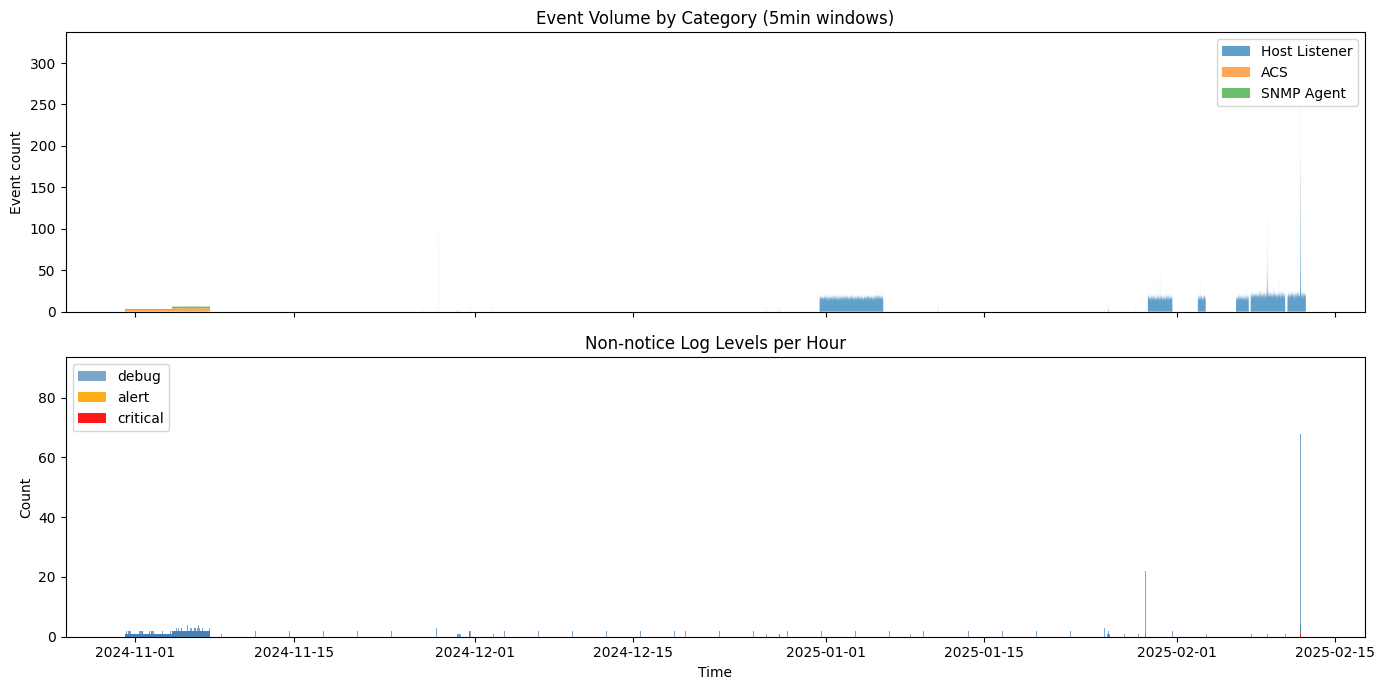

In [10]:
# Plot category counts over time
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].stackplot(
    agg_result.index,
    agg_result['category_Host Listener_count'],
    agg_result['category_ACS_count'],
    agg_result['category_SNMP Agent_count'],
    labels=['Host Listener', 'ACS', 'SNMP Agent'],
    alpha=0.7,
)
axes[0].set_ylabel('Event count')
axes[0].set_title('Event Volume by Category (5min windows)')
axes[0].legend(loc='upper right')

axes[1].bar(agg_result.index, agg_result['level_debug_count'],
            width=0.03, color='steelblue', alpha=0.7, label='debug')
axes[1].bar(agg_result.index, agg_result['level_alert_count'],
            width=0.03, color='orange', alpha=0.9, label='alert')
axes[1].bar(agg_result.index, agg_result['level_critical_count'],
            width=0.03, color='red', alpha=0.9, label='critical')
axes[1].set_ylabel('Count')
axes[1].set_title('Non-notice Log Levels per Hour')
axes[1].legend()
axes[1].set_xlabel('Time')

plt.tight_layout()
plt.show()

---
## 4. StringAggregator — Custom Metrics

The `custom_metrics` parameter lets you define **global aggregation functions** that operate on the entire sub-DataFrame of each time window (not just a single column). This is the key difference from `column_metrics`.

### How it works

```python
custom_metrics = {
    'metric_name': callable,  # callable receives a sub-DataFrame (one time window)
}
```

Each callable:
- Receives a **sub-DataFrame** containing all rows that fall within a single time window
- Must return a **single scalar value** (int, float, string, etc.)
- Has access to **all columns** in the original DataFrame, enabling cross-column logic

### Comparison with other parameters

| Parameter | Scope | Use case |
|-----------|-------|----------|
| `column_metrics` | Single column | Standard aggregations (`count`, `nunique`, `mode`) or per-column callables |
| `category_count_columns` | Single column | Count occurrences of specific category values |
| `custom_metrics` | Entire sub-DataFrame | Cross-column logic, ratios, conditional counts, domain rules |

In [11]:
# Define custom metrics tailored to this HSM log data

def connection_accepted_count(group):
    """Count 'Accepted connection' messages — measures incoming traffic."""
    return group['message'].str.contains('Accepted connection', na=False).sum()

def socket_closed_count(group):
    """Count 'socket closed' messages — measures connection teardowns."""
    return group['message'].str.contains('socket.*closed', case=False, na=False).sum()

def connection_churn_ratio(group):
    """Ratio of closed sockets to accepted connections.
    Values > 1.0 may indicate connection instability.
    This is a cross-column metric: it uses both 'message' content and counts."""
    accepted = group['message'].str.contains('Accepted connection', na=False).sum()
    closed = group['message'].str.contains('socket.*closed', case=False, na=False).sum()
    return closed / accepted if accepted > 0 else 0.0

def unique_client_ips(group):
    """Extract and count unique client IPs from 'Accepted connection' messages.
    Uses regex on the message column to parse out Client:x.x.x.x patterns."""
    accepted = group.loc[group['message'].str.contains('Client:', na=False), 'message']
    ips = accepted.str.extract(r'Client:([\d.]+)', expand=False).dropna().unique()
    return len(ips)

def non_listener_event_ratio(group):
    """Fraction of events that are NOT 'Host Listener'.
    Spikes indicate unusual activity from other subsystems (ACS, SNMP, System, etc.)."""
    if len(group) == 0:
        return 0.0
    return (group['category'] != 'Host Listener').sum() / len(group)

def has_critical_or_alert(group):
    """Binary flag: 1 if the window contains any alert or critical event."""
    return int(group['level'].isin(['alert', 'critical']).any())


my_custom_metrics = {
    'connections_accepted': connection_accepted_count,
    'sockets_closed': socket_closed_count,
    'churn_ratio': connection_churn_ratio,
    'unique_clients': unique_client_ips,
    'non_listener_ratio': non_listener_event_ratio,
    'has_severity_event': has_critical_or_alert,
}

print(f"Defined {len(my_custom_metrics)} custom metrics:")
for name in my_custom_metrics:
    print(f"  • {name}")

Defined 6 custom metrics:
  • connections_accepted
  • sockets_closed
  • churn_ratio
  • unique_clients
  • non_listener_ratio
  • has_severity_event


In [12]:
# Run aggregation with custom metrics
aggregator2 = StringAggregator(log_df, 'timestamp')

custom_result = aggregator2.create_time_aggregation(
    time_window='5min',
    column_metrics={
        'level': ['count'],
        'category': ['nunique'],
    },
    custom_metrics=my_custom_metrics,
)

display_cols = ['level_count', 'connections_accepted', 'sockets_closed',
                'churn_ratio', 'unique_clients', 'non_listener_ratio', 'has_severity_event']
print(f"Result shape: {custom_result.shape}")
custom_result[display_cols].head(15)

Result shape: (30049, 11)


,level_count,connections_accepted,sockets_closed,churn_ratio,unique_clients,non_listener_ratio,has_severity_event
2024-10-31 02:00:00,4,0,0,0.0,0,1.0,0
2024-10-31 02:05:00,3,0,0,0.0,0,1.0,0
2024-10-31 02:10:00,3,0,0,0.0,0,1.0,0
2024-10-31 02:15:00,4,0,0,0.0,0,1.0,0
2024-10-31 02:20:00,3,0,0,0.0,0,1.0,0
2024-10-31 02:25:00,3,0,0,0.0,0,1.0,0
2024-10-31 02:30:00,3,0,0,0.0,0,1.0,0
2024-10-31 02:35:00,3,0,0,0.0,0,1.0,0
2024-10-31 02:40:00,3,0,0,0.0,0,1.0,0
2024-10-31 02:45:00,3,0,0,0.0,0,1.0,0


### Interpreting the results

| Metric | What it tells you |
|--------|-------------------|
| `connections_accepted` | Incoming connection volume. Drops may indicate network issues. |
| `sockets_closed` | Connection teardowns. Should roughly track accepted connections. |
| `churn_ratio` | `closed / accepted`. Values significantly above 1.0 suggest connection instability or retries. |
| `unique_clients` | Number of distinct client IPs. Changes reveal shifts in traffic patterns. |
| `non_listener_ratio` | Fraction of non-listener events. Spikes mean other subsystems (ACS, SNMP, System) are active. |
| `has_severity_event` | Binary flag for alert/critical events. Useful for filtering windows that need attention. |

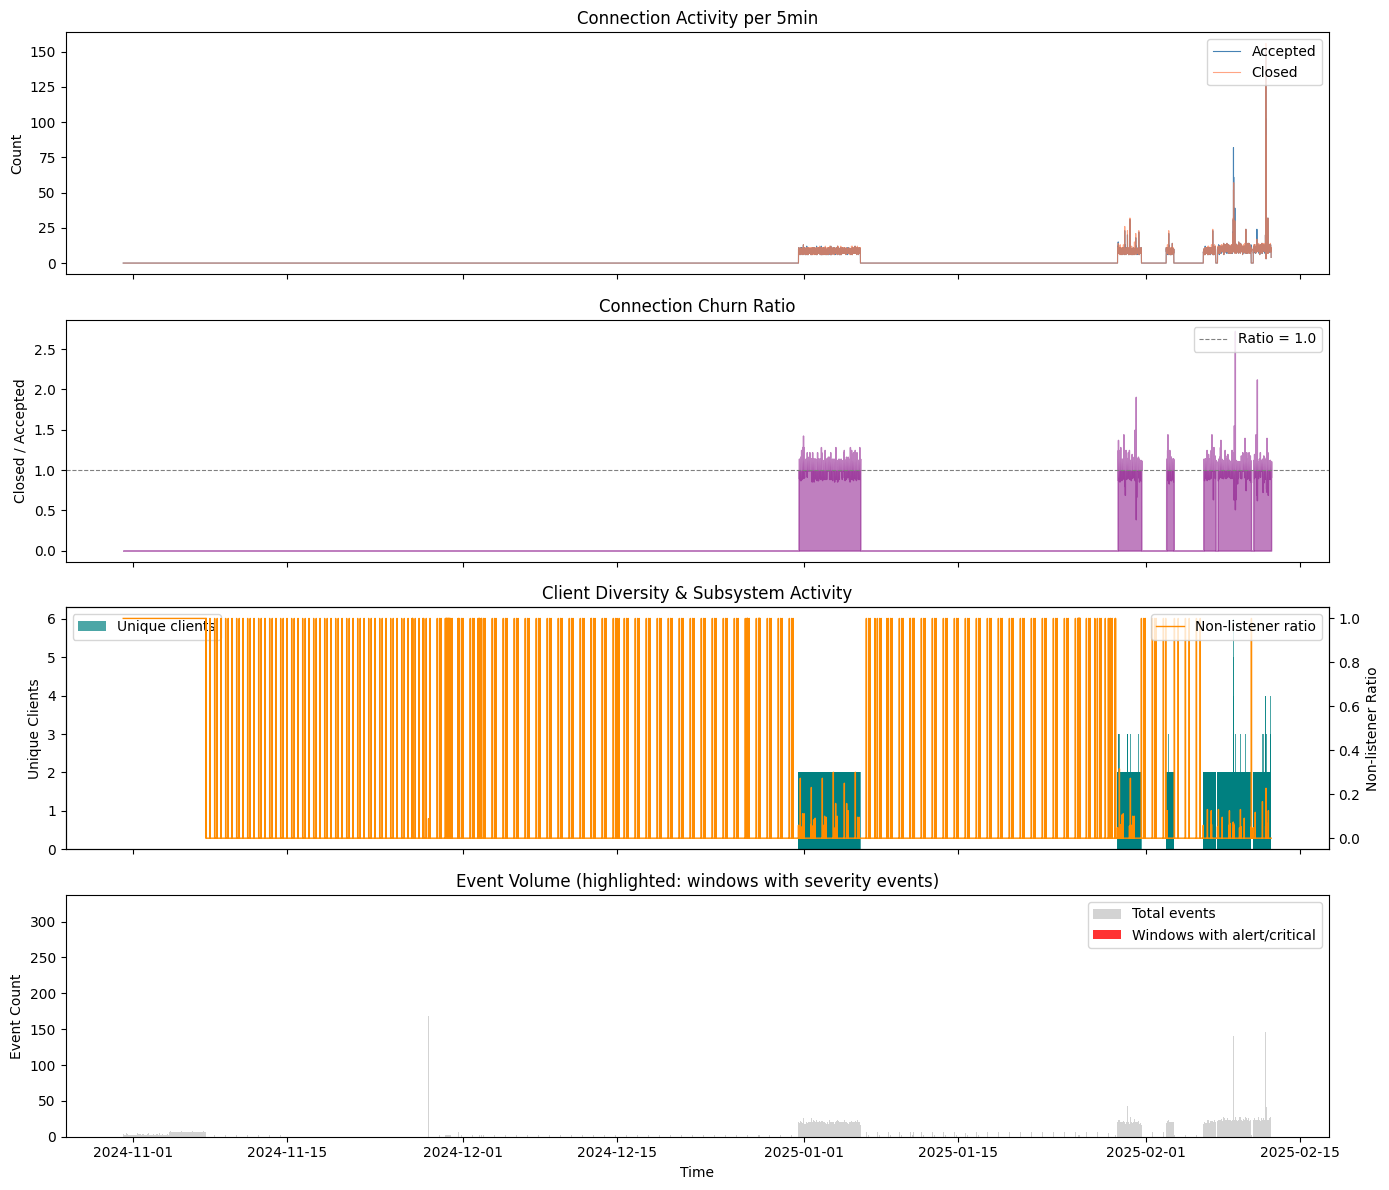

In [13]:
# Visualize custom metrics
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

# Connection volume
axes[0].plot(custom_result.index, custom_result['connections_accepted'],
             label='Accepted', color='steelblue', linewidth=0.8)
axes[0].plot(custom_result.index, custom_result['sockets_closed'],
             label='Closed', color='coral', linewidth=0.8, alpha=0.7)
axes[0].set_ylabel('Count')
axes[0].set_title('Connection Activity per 5min')
axes[0].legend(loc='upper right')

# Churn ratio
axes[1].fill_between(custom_result.index, custom_result['churn_ratio'],
                     alpha=0.5, color='purple')
axes[1].axhline(1.0, color='gray', linestyle='--', linewidth=0.8, label='Ratio = 1.0')
axes[1].set_ylabel('Closed / Accepted')
axes[1].set_title('Connection Churn Ratio')
axes[1].legend(loc='upper right')

# Unique clients + non-listener ratio
axes[2].bar(custom_result.index, custom_result['unique_clients'],
            width=0.03, color='teal', alpha=0.7, label='Unique clients')
ax2_twin = axes[2].twinx()
ax2_twin.plot(custom_result.index, custom_result['non_listener_ratio'],
              color='darkorange', linewidth=1, label='Non-listener ratio')
axes[2].set_ylabel('Unique Clients')
ax2_twin.set_ylabel('Non-listener Ratio')
axes[2].set_title('Client Diversity & Subsystem Activity')
axes[2].legend(loc='upper left')
ax2_twin.legend(loc='upper right')

# Severity events
severity_windows = custom_result[custom_result['has_severity_event'] == 1]
axes[3].bar(custom_result.index, custom_result['level_count'],
            width=0.03, color='lightgray', label='Total events')
if len(severity_windows) > 0:
    axes[3].bar(severity_windows.index, severity_windows['level_count'],
                width=0.03, color='red', alpha=0.8, label='Windows with alert/critical')
axes[3].set_ylabel('Event Count')
axes[3].set_xlabel('Time')
axes[3].set_title('Event Volume (highlighted: windows with severity events)')
axes[3].legend(loc='upper right')

plt.tight_layout()
plt.show()

### Tips for writing custom metrics

1. **Always handle empty groups**: Check `len(group) == 0` to avoid division by zero or empty Series errors.

2. **Return a scalar**: The function must return a single value (int, float, str). Returning a Series or DataFrame will break the aggregation.

3. **Cross-column logic is the main advantage**: Unlike `column_metrics` (which operates on one column at a time), `custom_metrics` receives the full sub-DataFrame, so you can combine multiple columns:
   ```python
   def acs_debug_events(group):
       return ((group['category'] == 'ACS') & (group['level'] == 'debug')).sum()
   ```

4. **Regex on message content**: Use `str.contains()` or `str.extract()` to parse unstructured message fields, as shown in `connection_accepted_count` and `unique_client_ips`.

5. **Combine with standard parameters**: All three parameters (`column_metrics`, `category_count_columns`, `custom_metrics`) work together. Use standard metrics for common cases and custom metrics for domain-specific logic.

6. **Performance**: Custom metrics use `groupby.apply()`, which is slower than built-in aggregations. For very large datasets, keep the logic inside each function simple and avoid repeated regex compilation.

---
## Summary

- `RollingAggregator`: rolling/expanding/EWM window stats on numeric data
- `StringAggregator`: time-window aggregation for categorical + numeric data
  - `column_metrics`: per-column standard aggregations
  - `category_count_columns`: count specific category values
  - `custom_metrics`: cross-column, domain-specific logic via callables
- Both produce DataFrames ready for anomaly detection